# Detekcja anomalii w obrazach mikroskopowych przy użyciu Autoenkodera

Celem projektu jest stworzenie systemu do automatycznego wykrywania anomalii w syntetycznych obrazach komórek. Wykorzystujemy metodę uczenia nienadzorowanego (unsupervised learning), w której model uczy się rekonstruować "zdrowe" obrazy.

**Koncepcja działania:**
1. Model trenowany jest wyłącznie na poprawnych danych.
2. Wysoki błąd rekonstrukcji (MSE) dla nowych danych sygnalizuje anomalię.
3. Wyniki weryfikowane są testem statystycznym t-Studenta.

## Architektura Modelu: Splotowy Autoenkoder (CNN)

Jako detektor wykorzystano głęboką sieć neuronową typu Autoenkoder. Składa się ona z dwóch części:
* **Enkoder:** Seria warstw konwolucyjnych (4 bloki redukujące wymiary), które kompresują obraz wejściowy $128 \times 128 \times 3$ do skompresowanej reprezentacji cech (latent space).
* **Dekoder:** Symetryczna struktura odtwarzająca obraz do oryginalnych wymiarów.

Jako funkcję błędu przyjęto `Binary Crossentropy`, a metryką detekcji anomalii jest błąd średniokwadratowy (MSE).

## Scenariusze Eksperymentalne

Przeprowadzono serię testów sprawdzających wrażliwość modelu na różne typy defektów. Dla każdego przypadku porównujemy rozkład MSE zdrowych komórek z anomaliami:

1.  **Zmiana skali:** Komórki o nienaturalnie dużym promieniu.
2.  **Zmiana koloru:** Anomalie w barwie jądra i cytoplazmy.
3.  **Zaburzony rozkład:** Zmiana algorytmu rozmieszczenia komórek (skupiska/klastry).
4.  **Deformacja kształtu:** Zastosowanie szumu Perlina do zniekształcenia krawędzi.
5.  **Anomalia złożona:** Połączenie wielu defektów jednocześnie.

## Weryfikacja Statystyczna (Test t-Studenta)

Aby potwierdzić, że wykryte różnice w błędzie rekonstrukcji (MSE) są istotne i nie wynikają z losowego doboru próby ("szczęśliwego trafu"), zastosowano **test t-Studenta dla prób niezależnych** (z poprawką Welcha na nierówną wariancję).

* **Hipoteza $H_0$:** Średni błąd rekonstrukcji dla anomalii i normy jest taki sam.
* **Wartość $p < 0.05$:** Oznacza statystycznie istotne wykrycie anomalii przez model.

In [1]:
from builders.simple_generator import generate_batch
from src.builders.image_builder import ImageGenerator
from builders.config import GenerationConfig
from src.visualization.visualize_output import show_images
from src.functions.otsu_function import detect_anomaly_otsu_mse

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import random
import keras
import numpy as np
from scipy.stats import ttest_ind
from src.visualization.visualize_output import visualize_output
from src.models.encoder_convolutional import Encoder_conv
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Eksperyment pierwszy
Eksperyment, w którym definiujemy dwa zbiory z różnicami w wielkości komórek. Utworzone zostaną dwa zbiory z różnicą w rozmiarze komórek w zbiorze testowym. Ma to na celu sprawdzenie czy istnieje
różnica w MSE.

Konfiguracja zbiorów

In [2]:
larger_cells_images_conf = GenerationConfig()
larger_cells_images_conf.axes.mean_x = 22
larger_cells_images_conf.axes.mean_y = 16
larger_cells_images_conf.axes.std_x = 6
larger_cells_images_conf.distribution.radius = 40

larger_cells = ImageGenerator(larger_cells_images_conf)

Utworzenie zbioru i sprawdzenie wyników

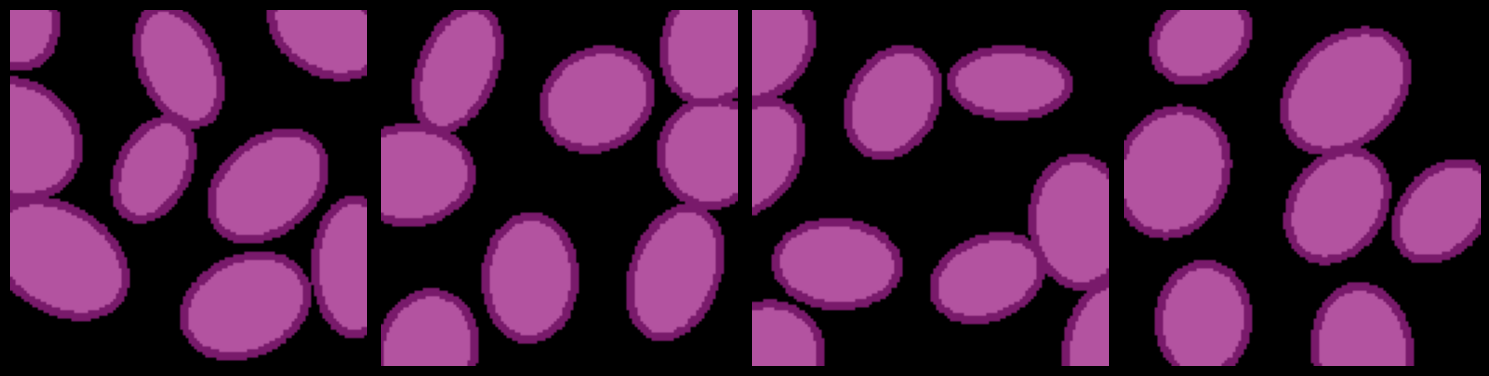

In [3]:
larger_cells_set = larger_cells.build_batch(2000)

show_images(larger_cells_set[:4])

### Eksperyment drugi
Eksperyment ma na celu sprawdzenie błędu MSE w sytuacji gdy zmienia się kolor komórek.

Konfiguracja komórki

In [4]:
different_colors_conf = GenerationConfig()
different_colors_conf.nucleus.base_color = (134, 80, 34)
different_colors_conf.nucleus.border_color = (29, 40, 182)

different_colors_cells = ImageGenerator(different_colors_conf)

Utworzenie zbioru i sprawdzenie wyników

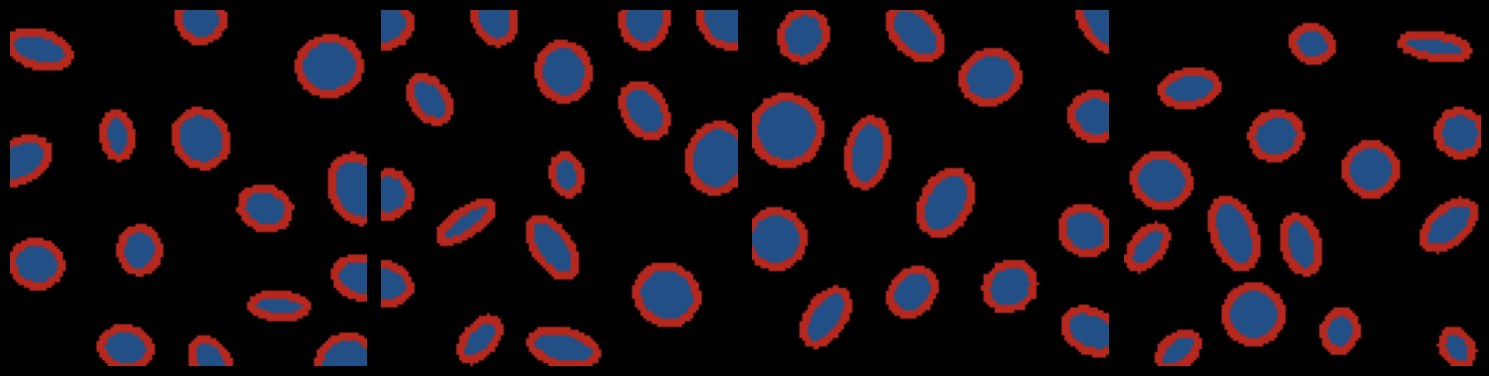

In [5]:
different_color_cells_set = different_colors_cells.build_batch(2000)

show_images(different_color_cells_set[:4])

### Eksperyment trzeci
W eksperymencie sprawdzone zostanie wpływ rozkładu komórek na błąd MSE.

Konfiguracja komórki

In [6]:
distribution_conf = GenerationConfig()
distribution_conf.distribution.algorithm = "gaussian"

gaussian_dist_cells = ImageGenerator(distribution_conf)

Utworzenie zbioru i sprawdzenie wyników

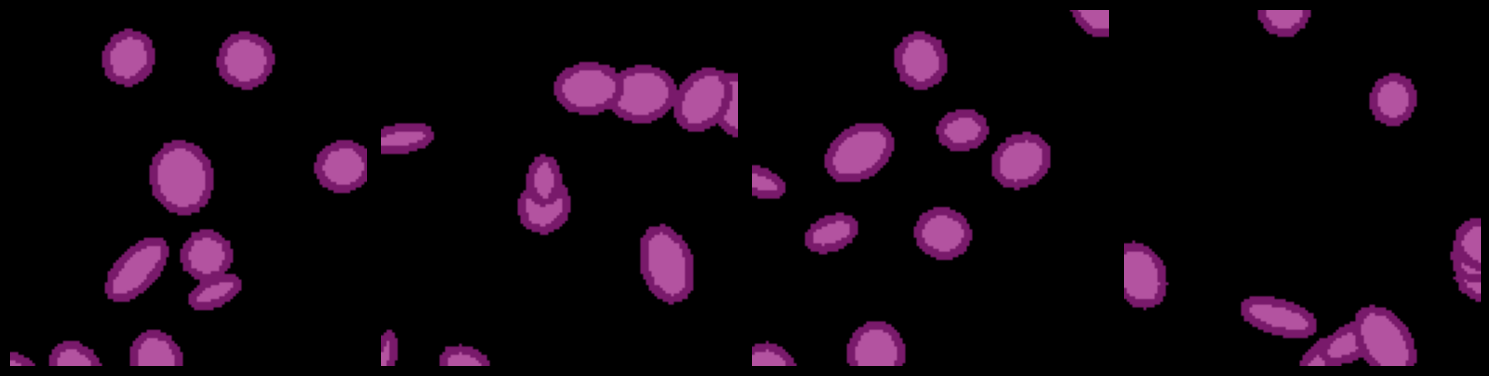

In [7]:
gaussian_dist_set = gaussian_dist_cells.build_batch(2000)

show_images(gaussian_dist_set[:4])

### Eksperyment czwarty
Sprawdzenie wpływu zniekształcenia kształtu komórek za pomocą szumu perlina na wynik MSE.

In [8]:
perlin_noise_conf = (ImageGenerator()
                     .with_perlin_noise(True))

Utworzenie zbioru i sprawdzenie wyników.

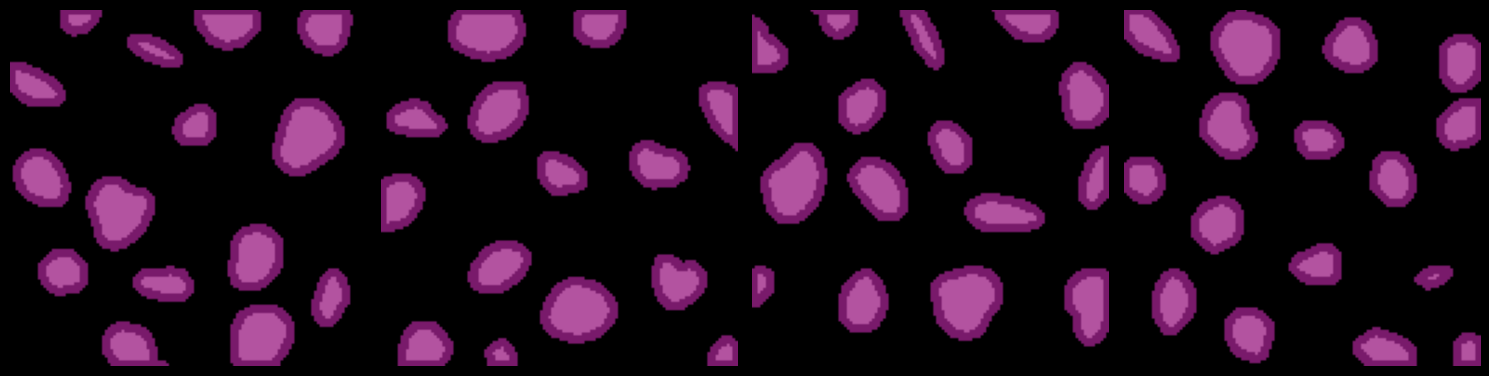

In [9]:
perlin_noise_set = perlin_noise_conf.build_batch(2000)

show_images(perlin_noise_set[:4])

### Eksperyment piąty

Połączenie wszystkich dotychczasowych eksperymentów.


In [10]:
various_conf = (ImageGenerator()
                .with_axes_config(16,18)
                .with_perlin_noise(True)
                .with_clustered_distribution(deviation=1)
                .with_cancer_cells(color=(23,190,40),
                                   border_color=(80,23,22)))

Utworzenie zbioru i sprawdzenie wyników.

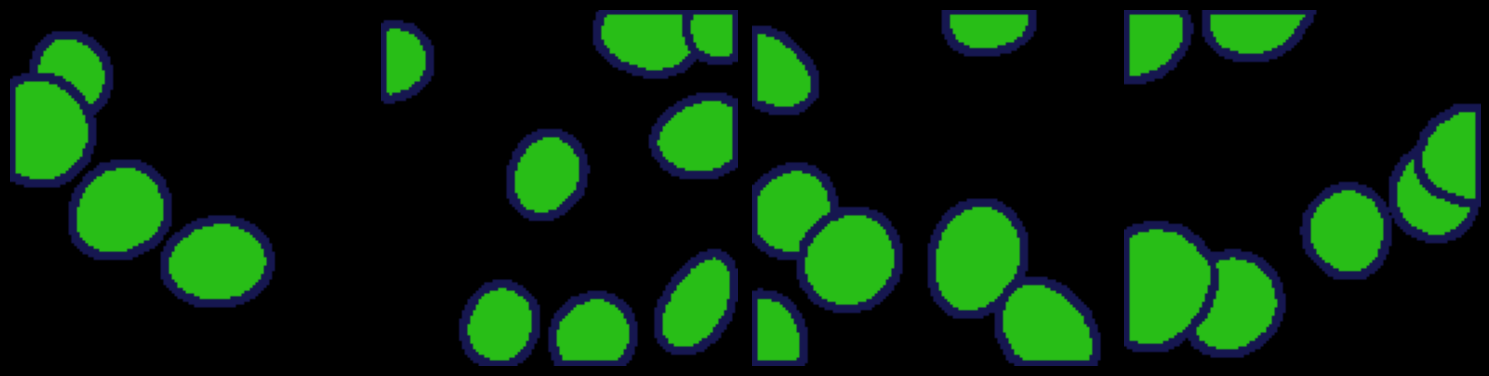

In [11]:
various_conf_set = various_conf.build_batch(2000)
show_images(various_conf_set[:4])

In [78]:
from builders.simple_generator import generate_image
%matplotlib inline

import cv2
from matplotlib import pyplot as plt


def show_images(images, titles=None, figsize=(25, 15)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for i, (img, ax) in enumerate(zip(images, axes)):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        if titles:

            ax.set_title(titles[i],fontsize=30)

    plt.tight_layout()
    plt.show()

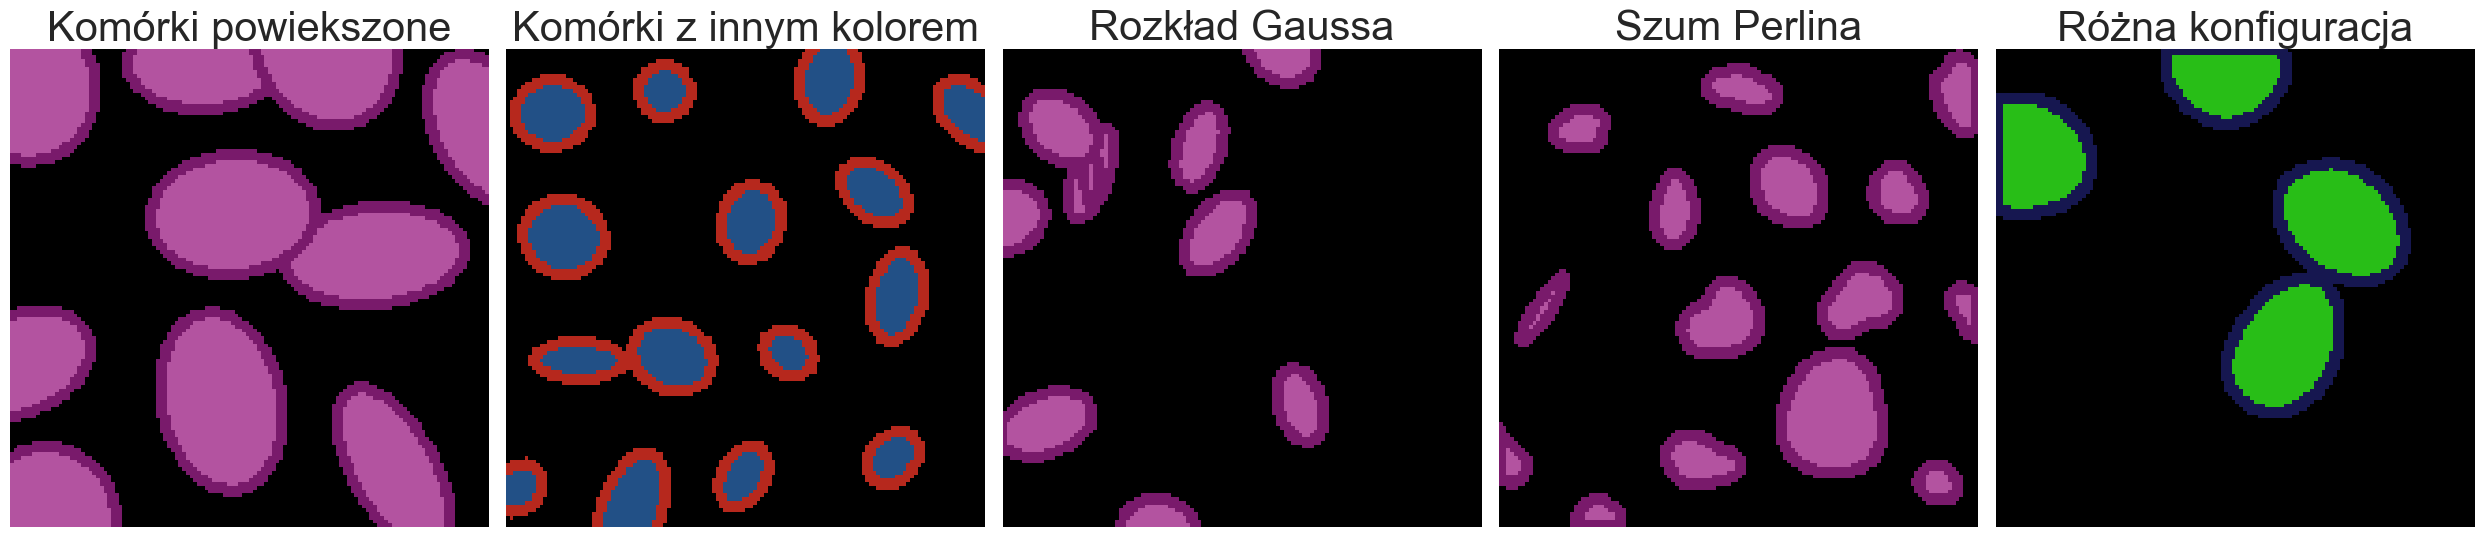

In [79]:
idx = random.randint(0,2000)

show_images([larger_cells_set[idx], different_color_cells_set[idx] ,gaussian_dist_set[idx],perlin_noise_set[idx],various_conf_set[idx]],
           ['Komórki powiekszone', 'Komórki z innym kolorem', 'Rozkład Gaussa', 'Szum Perlina', 'Różna konfiguracja'])

## Enkoder

Przygorowanie zbioru treningowego, walidacyjnego oraz testowego

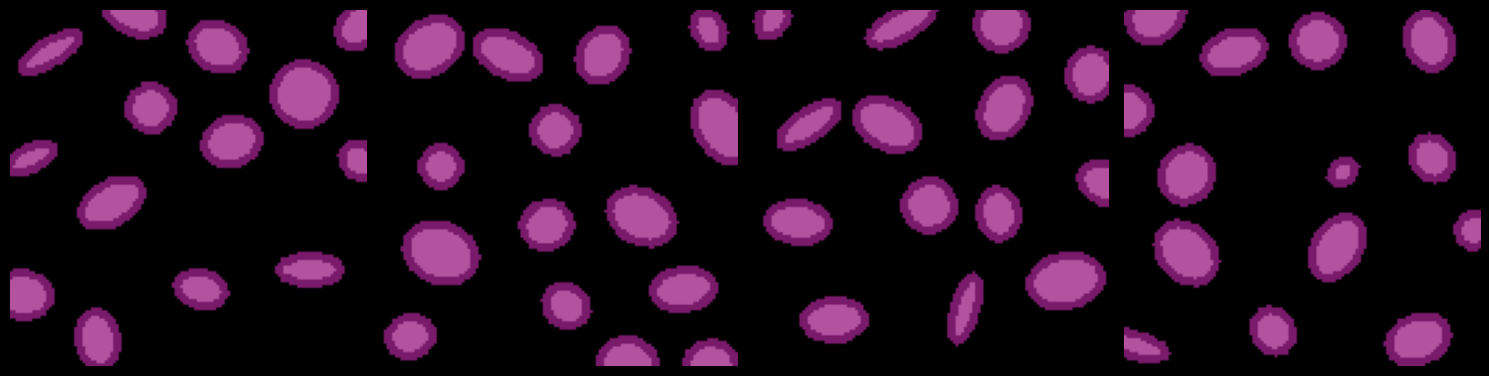

In [12]:
training_set = generate_batch(5000)

show_images(training_set[:4])

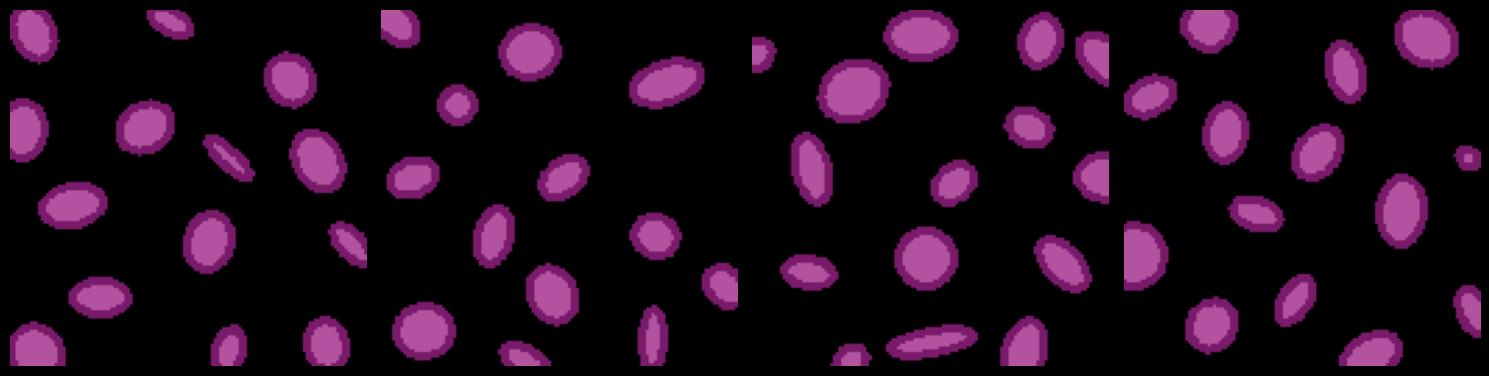

In [13]:
validation_set = generate_batch(1000)

show_images(validation_set[:4])

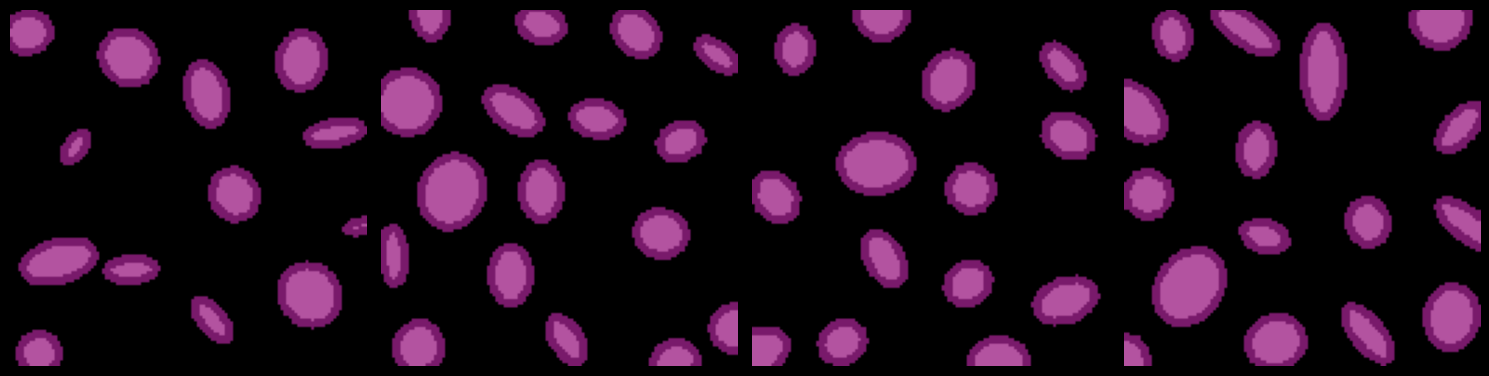

In [14]:
test_set = generate_batch(2000)

show_images(test_set[:4])

Przygotowanie danych dla enkodera

In [15]:
def preprocess(data_list):
    return np.array(data_list, dtype='float32') / 255.

In [16]:
x_test_data = preprocess(test_set)
x_val_data = preprocess(validation_set)
x_traning_data = preprocess(training_set)

Inplementacja enkodera

In [17]:
enkoder = Encoder_conv()

enkoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=0.0001,
    restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1)

history = enkoder.fit(
    x_traning_data, x_traning_data,
    epochs=50,
    shuffle=True,
    callbacks=[reduce_lr, early_stopping],
    validation_data=(x_val_data, x_val_data),
    verbose=1)

print(f"\nTrening zakończony po {len(history.history['loss'])} epokach.")

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 288ms/step - accuracy: 0.8624 - loss: 0.1902 - mse: 0.0114 - val_accuracy: 0.9246 - val_loss: 0.1562 - val_mse: 0.0022 - learning_rate: 0.0010
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 278ms/step - accuracy: 0.9253 - loss: 0.1554 - mse: 0.0018 - val_accuracy: 0.8789 - val_loss: 0.1528 - val_mse: 0.0015 - learning_rate: 0.0010
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.7780 - loss: 0.1540 - mse: 0.0015 - val_accuracy: 0.5811 - val_loss: 0.1519 - val_mse: 0.0011 - learning_rate: 0.0010
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.6167 - loss: 0.1524 - mse: 0.0010 - val_accuracy: 0.6394 - val_loss: 0.1510 - val_mse: 9.6660e-04 - learning_rate: 0.0010
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.6483 - loss: 0.1521 - mse: 9.7431e-04 - val_accuracy: 0.6772 - val_loss: 0.1507 - val_mse: 8.8098e-04 - learning_rate: 0.0010
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/ste

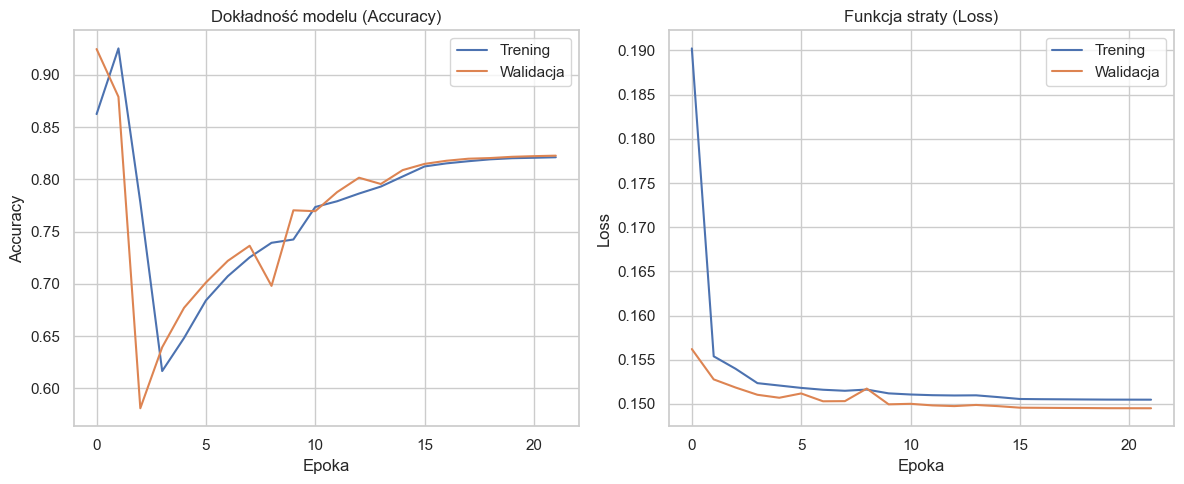

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.title('Dokładność modelu (Accuracy)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.title('Funkcja straty (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
MSE Normal: 0.000557


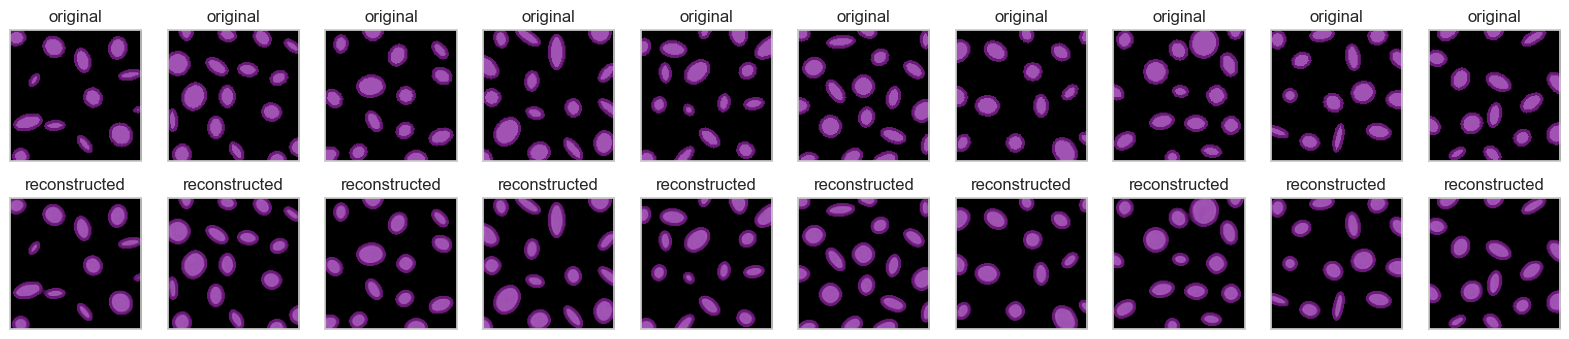

In [19]:
decoded_test = enkoder.predict(x_test_data)
mse_test = enkoder.evaluate(x_test_data, x_test_data, verbose=0)[2]

print(f"MSE Normal: {mse_test:.6f}")

visualize_output(x_test_data, decoded_test, 10)

Wykres błedu MSE

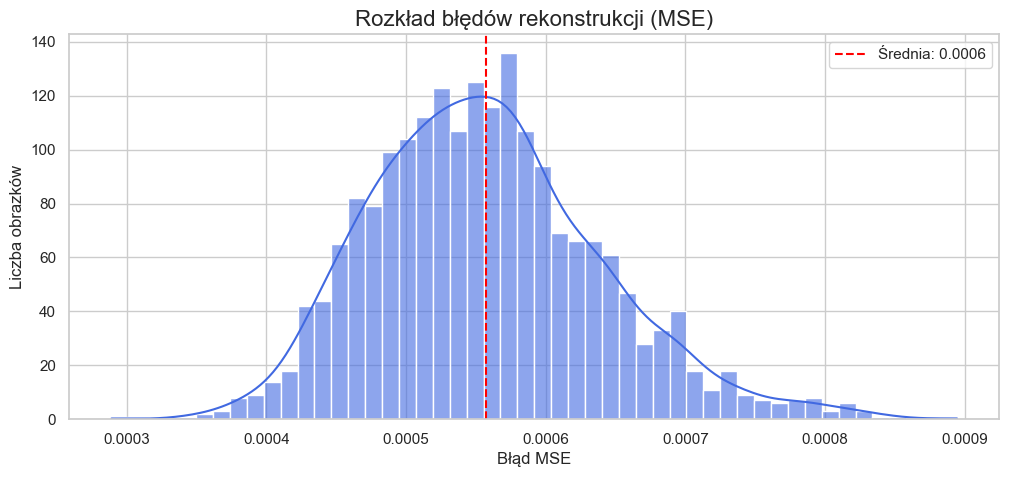

In [20]:
mse_test_per_image = np.mean(np.square(x_test_data - decoded_test), axis=(1, 2, 3))

plt.figure(figsize=(12, 5))

sns.histplot(mse_test_per_image, bins=50, kde=True, color="royalblue", alpha=0.6)

mean_val_test = np.mean(mse_test_per_image)
plt.axvline(mean_val_test, color='red', linestyle='--', label=f'Średnia: {mean_val_test:.4f}')

plt.title("Rozkład błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [21]:
test = [{'Eksperyment': 'MSE test', 'Wynik': mse_test}]

mse_dataset = pd.DataFrame(test, columns=['Eksperyment', 'Wynik'])
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557


### Wyniki eksperymentu pierwszego

63/63 - 2s - 35ms/step - accuracy: 0.8336 - loss: 0.3317 - mse: 0.0011
MSE Large:  0.001055


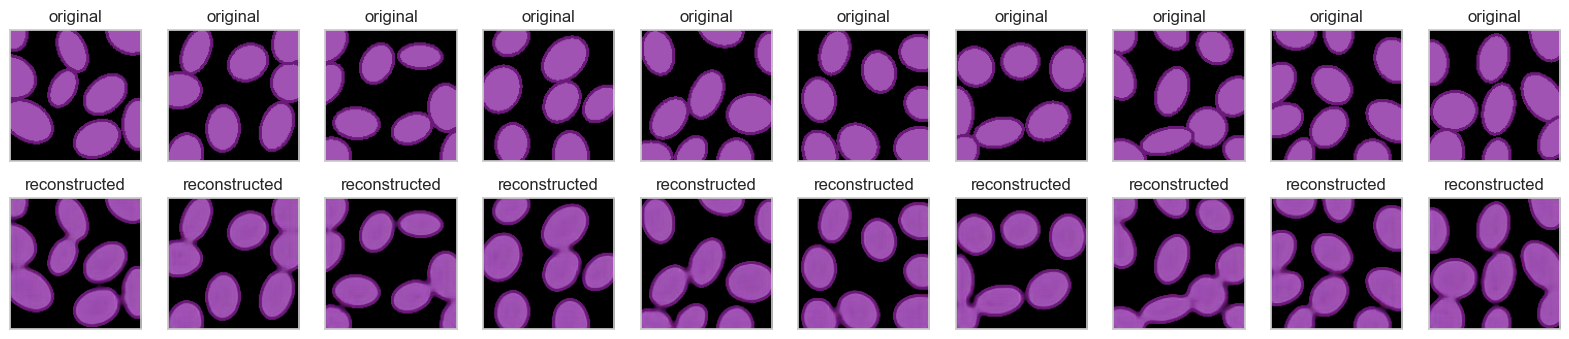

In [22]:
x_large_cells_data = preprocess(larger_cells_set)

decoded_large_cells = enkoder.predict(x_large_cells_data, verbose = 0)
mse_large = enkoder.evaluate(x_large_cells_data, x_large_cells_data, verbose=2)[2]

print(f"MSE Large:  {mse_large:.6f}")

visualize_output(x_large_cells_data, decoded_large_cells, 10)

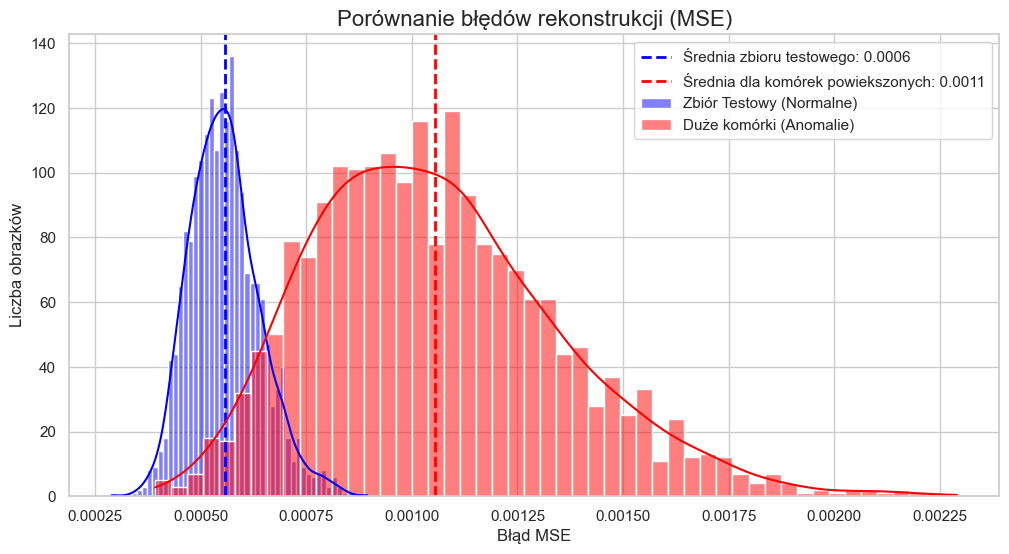

In [23]:

mse_large_per_image = np.mean(np.square(x_large_cells_data - decoded_large_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
plt.axvline(mean_val_test, color='blue', linestyle='--', label=f'Średnia zbioru testowego: {mean_val_test:.4f}',linewidth=2)
sns.histplot(mse_large_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Duże komórki (Anomalie)')
mean_val_larger_cells = np.mean(mse_large_per_image)

plt.axvline(mean_val_larger_cells, color='red', linestyle='--', label=f'Średnia dla komórek powiekszonych: {mean_val_larger_cells:.4f}',linewidth=2)
plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

**Hipoteza zerowa**

Zakładamy, że wartość średniego błędu MSE dla normalnych komórek jest taka sama jak dla anomalii. (Wariant pesymistyczny)

**Hipoteza alternatywna**

Średni błąd Mse dla anomalii jest większy niż komórek normalnych

**Aby wyeliminować podejrzenie losowości w wynikach MSE zastosowano test t-studenta dla błędu MSE.**

Interpretacja:
* Jeżeli p_value jest mniejsze niż 0.05 oznacza to, że szansa na to, że wynik uzyskaliśmy przez losowe zbiegnięcie się danych jest mniejsza niż 0.0001% i jest praktycznie niemożliwa. Odrzucamy hipotezę o szczęściu w losowaniu obrazów i model działa.
* Jeżeli p_value jest większe od 0.05 oznacza to, że istnieje ryzyko, że różnica wynika z przypadku. Pesymistyczna hipoteza zerowa mogła mieć miejsce.

In [24]:
t_stat1, p_val1 = ttest_ind(mse_large_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat1:.4f}")
print(f"P-value: {p_val1:.30f}")

Statystyka t: 73.1399
P-value: 0.000000000000000000000000000000


In [25]:
larger_cells = [{'Eksperyment': 'MSE for larger cells', 'Wynik': mse_large}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(larger_cells)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557
1,MSE for larger cells,0.001055


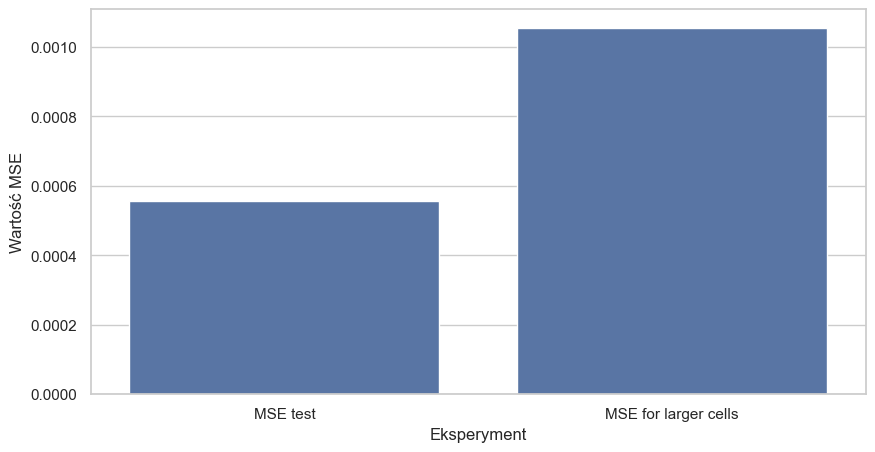

In [26]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

### Wyniki eksperymentu drugiego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6769 - loss: 0.1788 - mse: 0.0189
MSE of cells with different colors:  0.018857


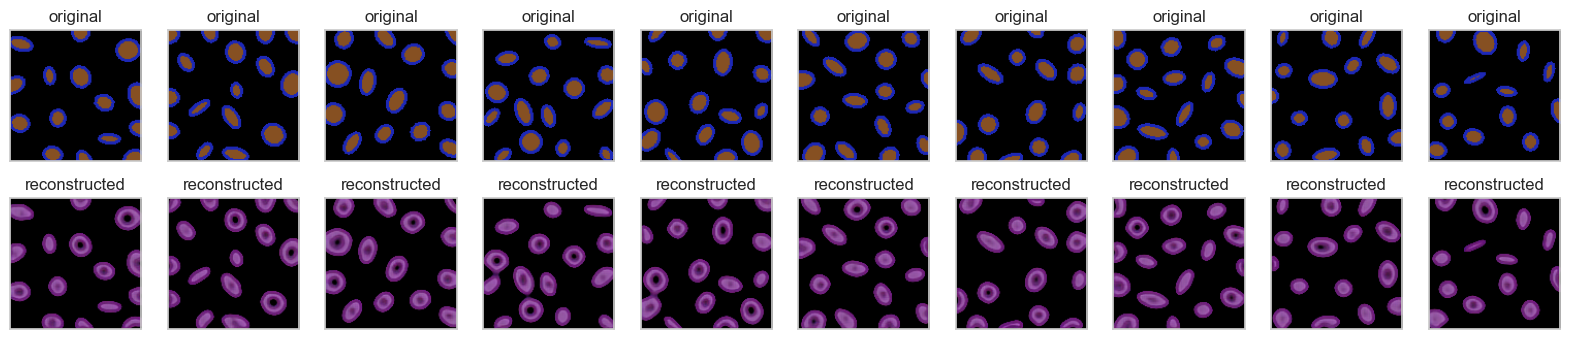

In [27]:
x_diff_color_cells_data = preprocess(different_color_cells_set)

decoded_diff_colors_cells = enkoder.predict(x_diff_color_cells_data,verbose = 0)
mse_color = enkoder.evaluate(x_diff_color_cells_data, x_diff_color_cells_data, verbose=1)[2]

print(f"MSE of cells with different colors:  {mse_color:.6f}")

visualize_output(x_diff_color_cells_data, decoded_diff_colors_cells, 10)

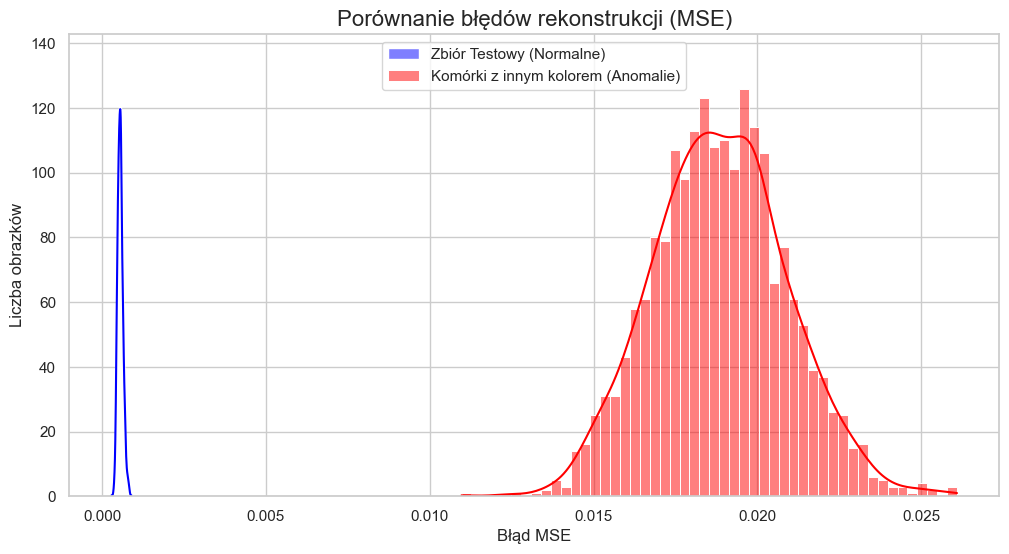

In [28]:
mse_diff_color_per_image = np.mean(np.square(x_diff_color_cells_data - decoded_diff_colors_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [29]:
t_stat2, p_val2 = ttest_ind(mse_diff_color_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat2:.4f}")
print(f"P-value: {p_val2:.30f}")

Statystyka t: 400.8173
P-value: 0.000000000000000000000000000000


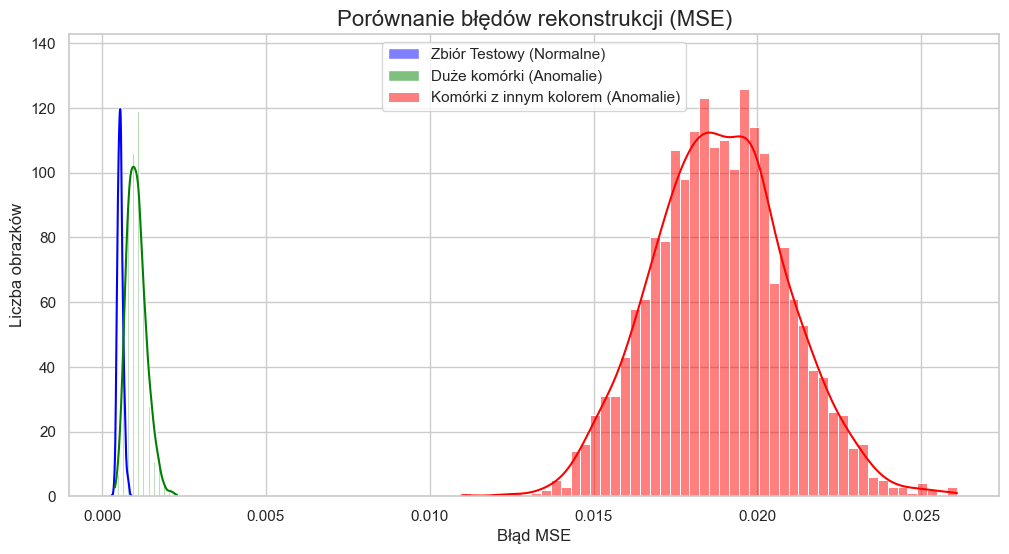

In [30]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')
sns.histplot(mse_large_per_image, bins=50, kde=True,
             color='green', alpha=0.5, label='Duże komórki (Anomalie)')
sns.histplot(mse_diff_color_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z innym kolorem (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [31]:
diff_color_cells = [{'Eksperyment': 'MSE with different color', 'Wynik': mse_color}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(diff_color_cells)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557
1,MSE for larger cells,0.001055
2,MSE with different color,0.018857


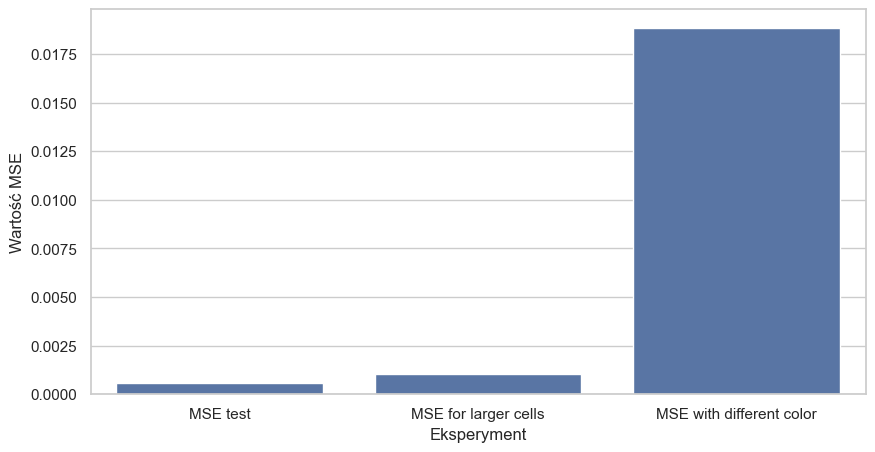

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

### Wyniki eksperymentu trzeciego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
MSE with Gauss's distribution:  0.000616


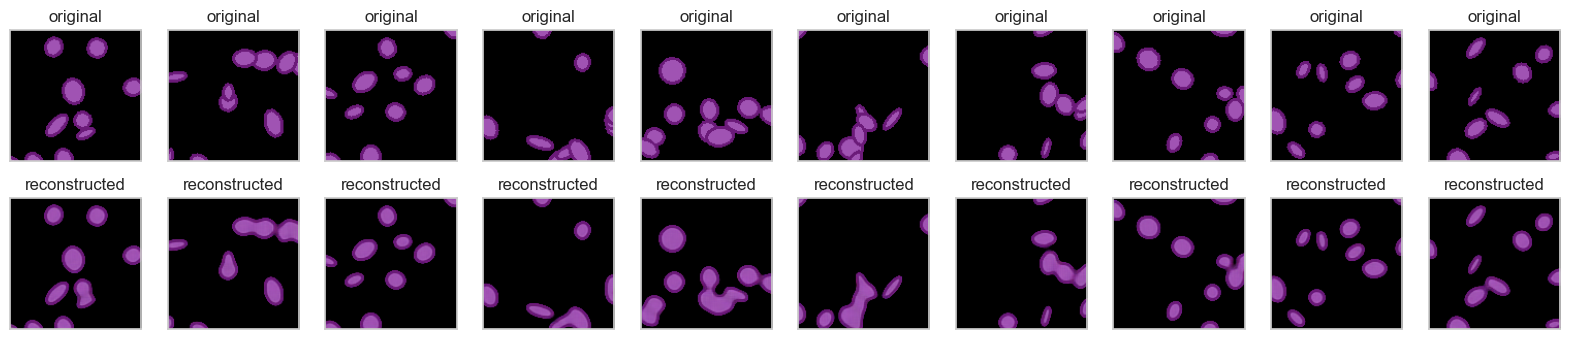

In [33]:
x_gaussian_dist_data = preprocess(gaussian_dist_set)

decoded_gaussian_dist_cells = enkoder.predict(x_gaussian_dist_data)
mse_gaussian = enkoder.evaluate(x_gaussian_dist_data,x_gaussian_dist_data,verbose = 0)[2]

print(f"MSE with Gauss's distribution:  {mse_gaussian:.6f}")

visualize_output(x_gaussian_dist_data, decoded_gaussian_dist_cells, 10)

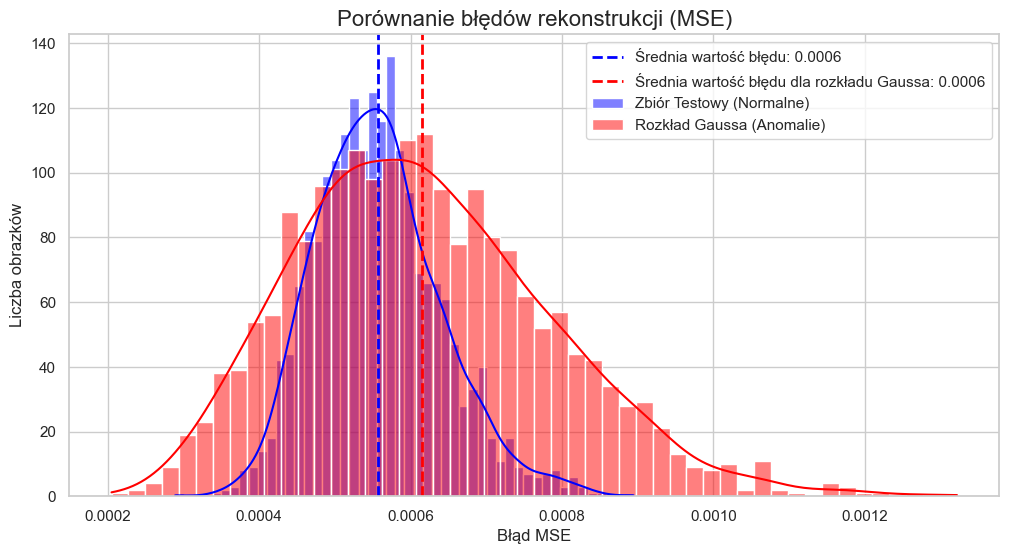

In [34]:
mse_gaussian_per_image = np.mean(np.square(x_gaussian_dist_data - decoded_gaussian_dist_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image,
             bins=50, kde=True,
             color='blue',
             alpha=0.5,
             label='Zbiór Testowy (Normalne)')
plt.axvline(mean_val_test,
            color='blue',
            linestyle='--',
            linewidth=2,
            label=f'Średnia wartość błędu: {mean_val_test:.4f}')


mean_val_gauss_dist = np.mean(mse_gaussian_per_image)
sns.histplot(mse_gaussian_per_image,
             bins=50,
             kde=True,
             color='red',
             alpha=0.5,
             label='Rozkład Gaussa (Anomalie)')
plt.axvline(mean_val_gauss_dist,
            color='red',
            linestyle='--',
            linewidth=2,
            label= f'Średnia wartość błędu dla rozkładu Gaussa: {mean_val_gauss_dist:.4f}')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [35]:
t_stat3, p_val3 = ttest_ind(mse_gaussian_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat3:.4f}")
print(f"P-value: {p_val3:.30f}")

Statystyka t: 13.9867
P-value: 0.000000000000000000000000000000


In [36]:
gaussian_dist = [{'Eksperyment': "MSE with Gauss's distribution", 'Wynik': mse_gaussian}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(gaussian_dist)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557
1,MSE for larger cells,0.001055
2,MSE with different color,0.018857
3,MSE with Gauss's distribution,0.000616


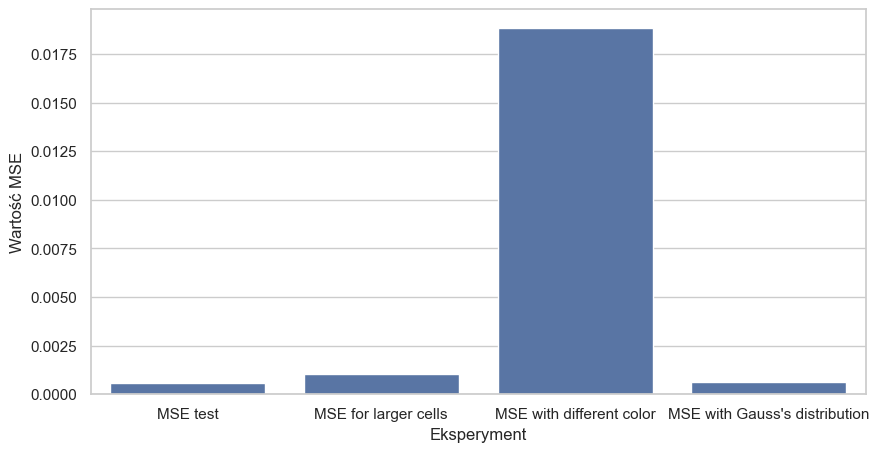

In [37]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Wyniki eksperymentu czwartego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
MSE of cells with Perlin Noise:  0.000899


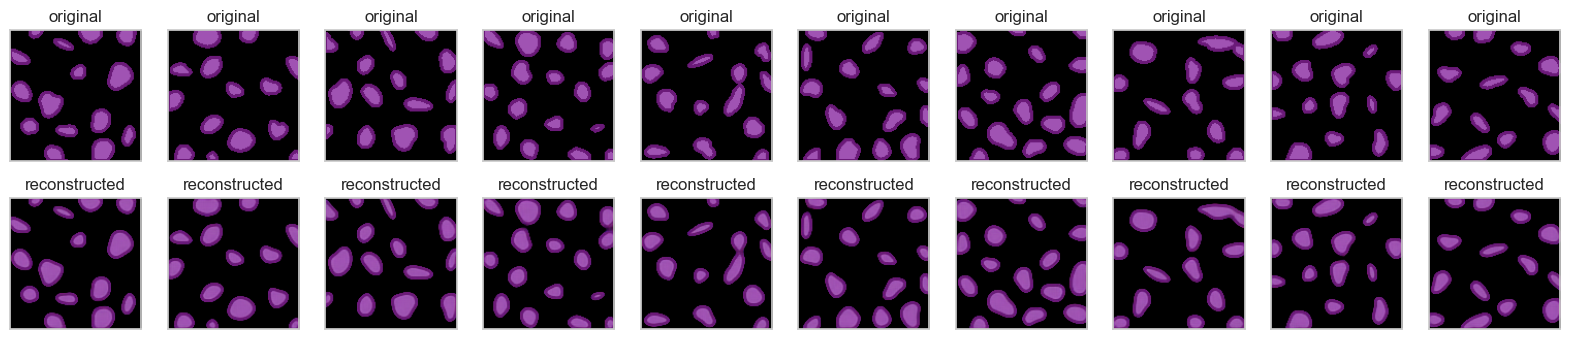

In [38]:
x_perlin_data = preprocess(perlin_noise_set)

decoded_perlin_noise_cells = enkoder.predict(x_perlin_data)
mse_perlin = enkoder.evaluate(x_perlin_data,x_perlin_data,verbose = 0)[2]

print(f"MSE of cells with Perlin Noise:  {mse_perlin:.6f}")

visualize_output(x_perlin_data, decoded_perlin_noise_cells, 10)

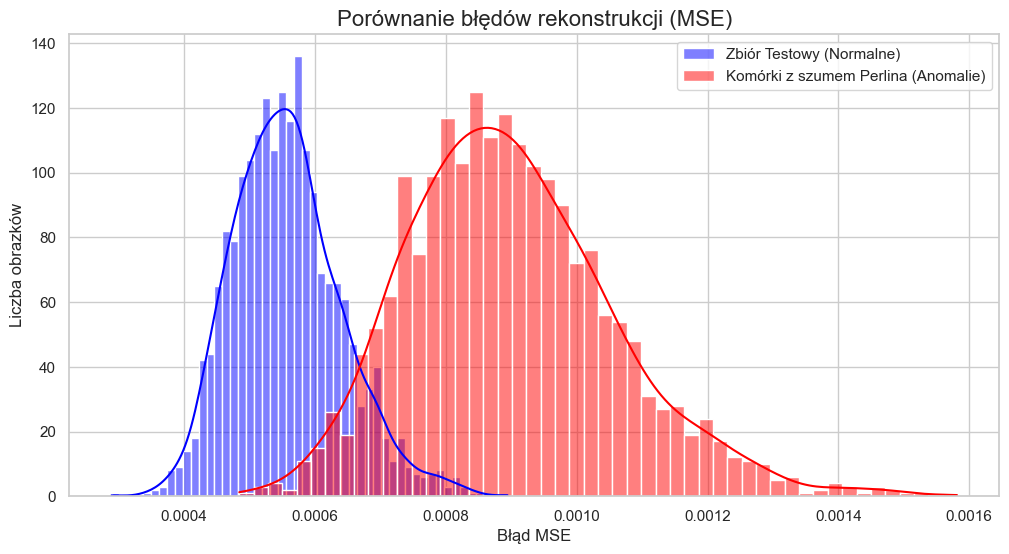

In [39]:
mse_perlin_per_image = np.mean(np.square(x_perlin_data - decoded_perlin_noise_cells), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_perlin_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Komórki z szumem Perlina (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [40]:
t_stat4, p_val4 = ttest_ind(mse_perlin_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat4:.4f}")
print(f"P-value: {p_val4:.30f}")

Statystyka t: 85.7583
P-value: 0.000000000000000000000000000000


In [41]:
perlin_cells = [{'Eksperyment': "MSE with Perlin Noise", 'Wynik': mse_perlin}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(perlin_cells)], ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557
1,MSE for larger cells,0.001055
2,MSE with different color,0.018857
3,MSE with Gauss's distribution,0.000616
4,MSE with Perlin Noise,0.000899


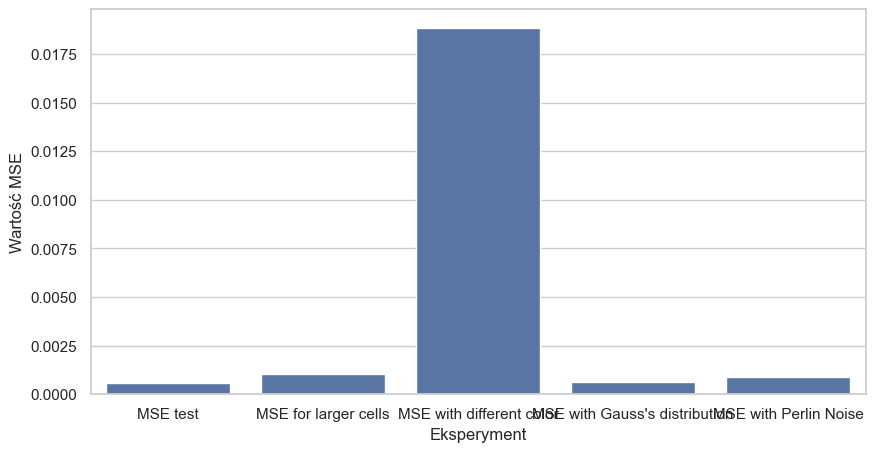

In [42]:
plt.figure(figsize=(10, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Wyniki eksperymentu piątego

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
MSE with various configuration:  0.040094


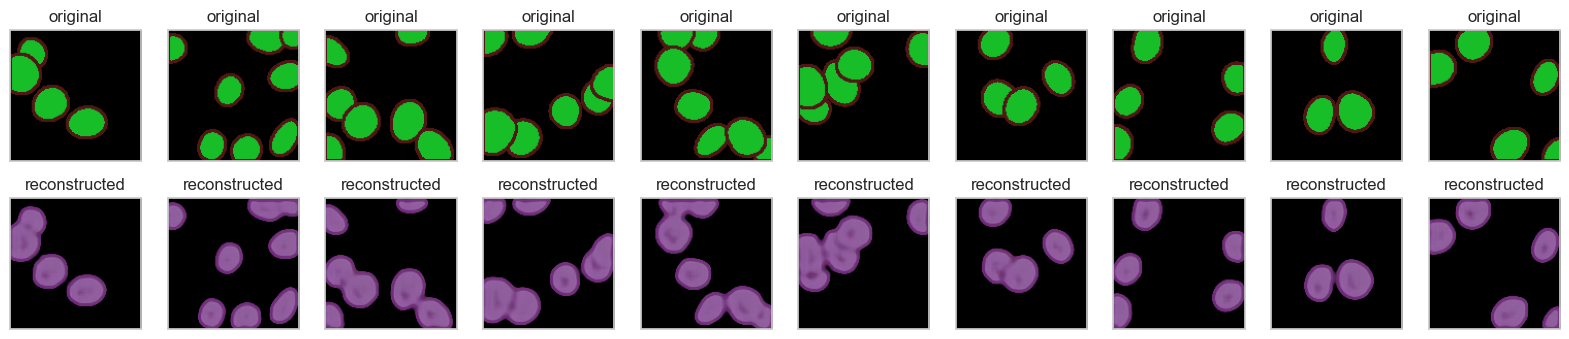

In [43]:
x_various_conf_data = preprocess(various_conf_set)

decoded_various_conf = enkoder.predict(x_various_conf_data)
mse_various_conf = enkoder.evaluate(x_various_conf_data,x_various_conf_data,verbose = 0)[2]

print(f"MSE with various configuration:  {mse_various_conf:.6f}")

visualize_output(x_various_conf_data, decoded_various_conf, 10)

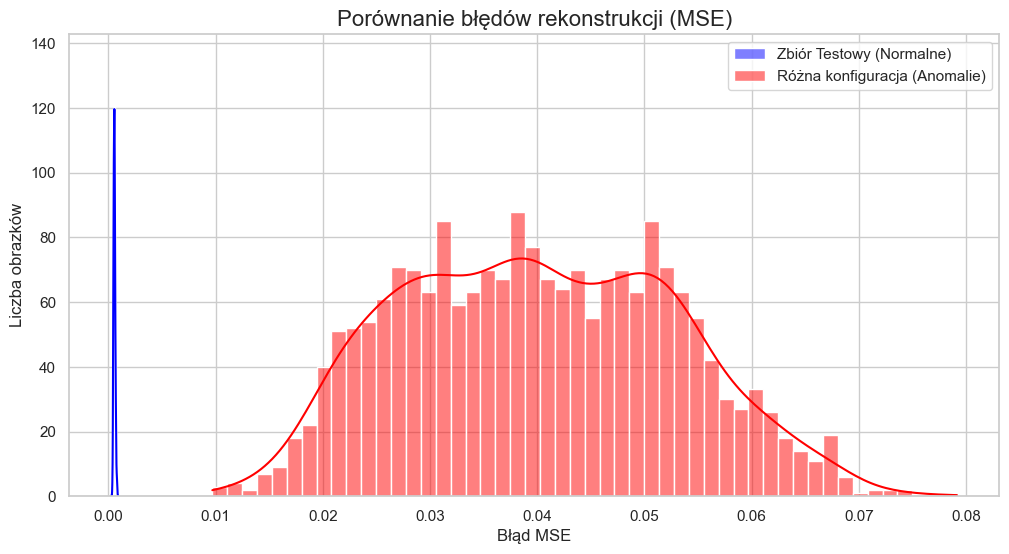

In [44]:
mse_various_per_image = np.mean(np.square(x_various_conf_data - decoded_various_conf), axis=(1, 2, 3))

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.histplot(mse_test_per_image, bins=50, kde=True,
             color='blue', alpha=0.5, label='Zbiór Testowy (Normalne)')

sns.histplot(mse_various_per_image, bins=50, kde=True,
             color='red', alpha=0.5, label='Różna konfiguracja (Anomalie)')

plt.title("Porównanie błędów rekonstrukcji (MSE)", fontsize=16)
plt.xlabel("Błąd MSE", fontsize=12)
plt.ylabel("Liczba obrazków", fontsize=12)

plt.legend()
plt.show()

In [45]:
t_stat5, p_val5 = ttest_ind(mse_various_per_image, mse_test_per_image,
                          equal_var=False, alternative='greater')

print(f"Statystyka t: {t_stat5:.4f}")
print(f"P-value: {p_val5:.30f}")

Statystyka t: 139.5115
P-value: 0.000000000000000000000000000000


In [46]:
various_conf = [{'Eksperyment': "MSE with various configuration", 'Wynik': mse_various_conf}]

mse_dataset = pd.concat([mse_dataset, pd.DataFrame(various_conf)],ignore_index=True)
mse_dataset

,Eksperyment,Wynik
0,MSE test,0.000557
1,MSE for larger cells,0.001055
2,MSE with different color,0.018857
3,MSE with Gauss's distribution,0.000616
4,MSE with Perlin Noise,0.000899
5,MSE with various configuration,0.040094


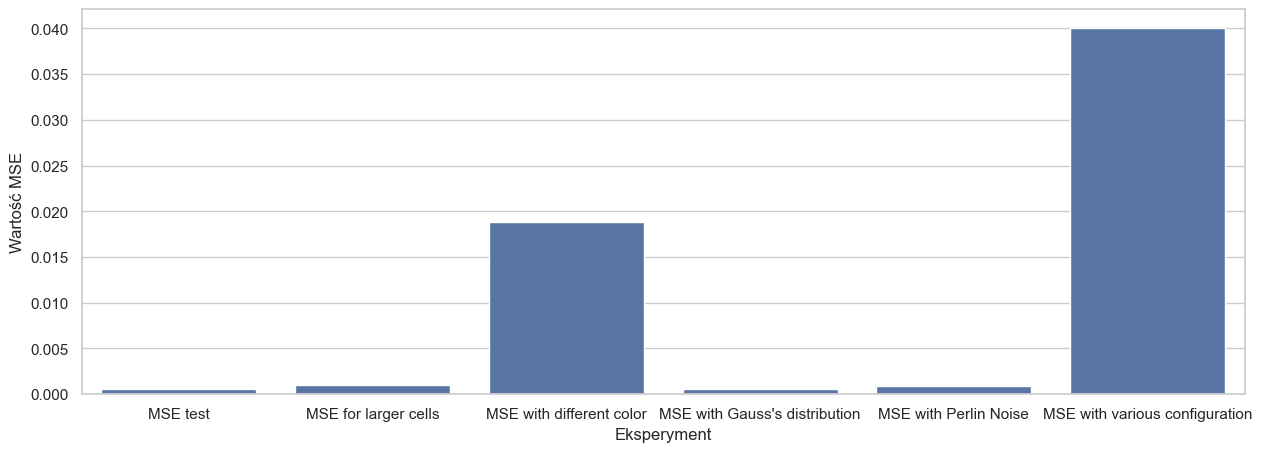

In [47]:
plt.figure(figsize=(15, 5))
sns.barplot(data=mse_dataset, y='Wynik',x='Eksperyment')
plt.ylabel("Wartość MSE")
plt.show()

Inplementacja Metody Otsu do automatycznego wyznaczania progu wykrycia anomalii

In [48]:
otsu_thresholds = []

for i in range(len(x_perlin_data)):
    input_data = x_perlin_data[i]
    output_data = decoded_perlin_noise_cells[i]

    calculated_threshold, anomaly_mask, error_map = detect_anomaly_otsu_mse(input_data,output_data)
    otsu_thresholds.append([calculated_threshold, anomaly_mask, error_map])




In [49]:
all_thresholds = [x[0] for x in otsu_thresholds]

In [50]:
print(f'Liczba uzyskanych progów: {len(all_thresholds)}')

Liczba uzyskanych progów: 2000


In [51]:
print(f'średni próg: {np.mean(all_thresholds)}')
print(f'najmniejsza wartość progu: {np.min(all_thresholds)}')
print(f'największa wartość progu: {np.max(all_thresholds)}')
print(f'std: {np.std(all_thresholds)}')

średni próg: 4.3165
najmniejsza wartość progu: 3.0
największa wartość progu: 7.0
std: 0.5807992338149217


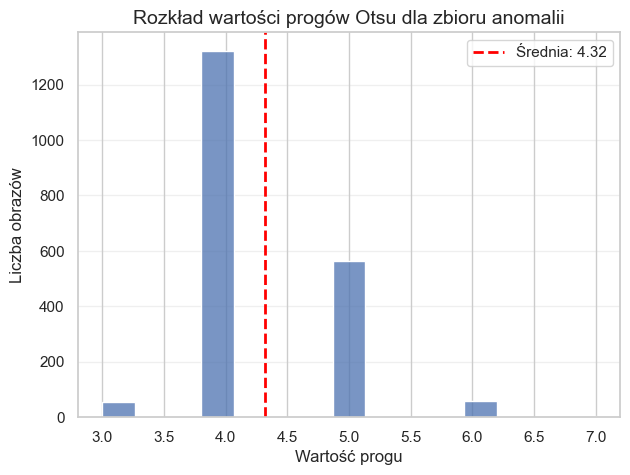

In [52]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
sns.histplot(x=all_thresholds, bins=15, kde=False)
plt.axvline(np.mean(all_thresholds), color='red', linestyle='--', linewidth=2, label=f'Średnia: {np.mean(all_thresholds):.2f}')

plt.title('Rozkład wartości progów Otsu dla zbioru anomalii', fontsize=14)
plt.xlabel('Wartość progu')
plt.ylabel('Liczba obrazów', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

In [53]:
idx = random.randint(0, len(otsu_thresholds)-1)

curr_org = x_perlin_data[idx]
curr_dec = decoded_perlin_noise_cells[idx]

idx_thresh = otsu_thresholds[idx][0]
idx_mask =  otsu_thresholds[idx][1]
idx_err = otsu_thresholds[idx][2]

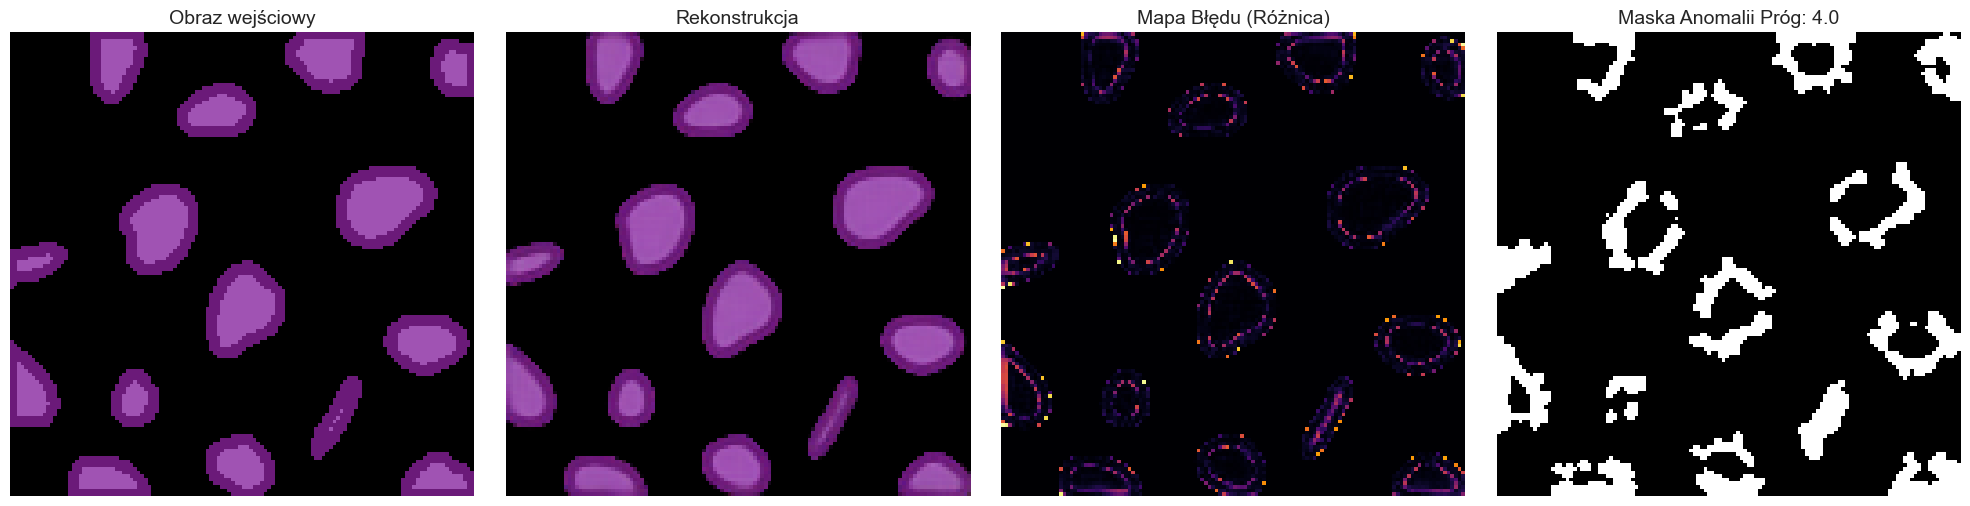

In [54]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 5))
plt.subplot(1,4,1)
plt.title("Obraz wejściowy", fontsize=14)
plt.imshow(curr_org)
plt.axis('off')


plt.subplot(1,4,2)
plt.title('Rekonstrukcja', fontsize=14)
plt.imshow(curr_dec)
plt.axis('off')


plt.subplot(1,4,3)
plt.imshow(idx_err, cmap='inferno')
plt.title("Mapa Błędu (Różnica)", fontsize=14)
plt.axis('off')

plt.subplot(1,4,4)

plt.imshow(curr_org)
plt.imshow(idx_mask, cmap='gray')

plt.title(f"Maska Anomalii Próg: {idx_thresh:.1f}", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

In [55]:
df_healthy = pd.DataFrame({'MSE': mse_test_per_image, 'Typ': 'Zdrowa'})
df_cancer = pd.DataFrame({'MSE': mse_perlin_per_image, 'Typ': 'Anomalia'})
df_results = pd.concat([df_healthy,df_cancer], ignore_index=True)

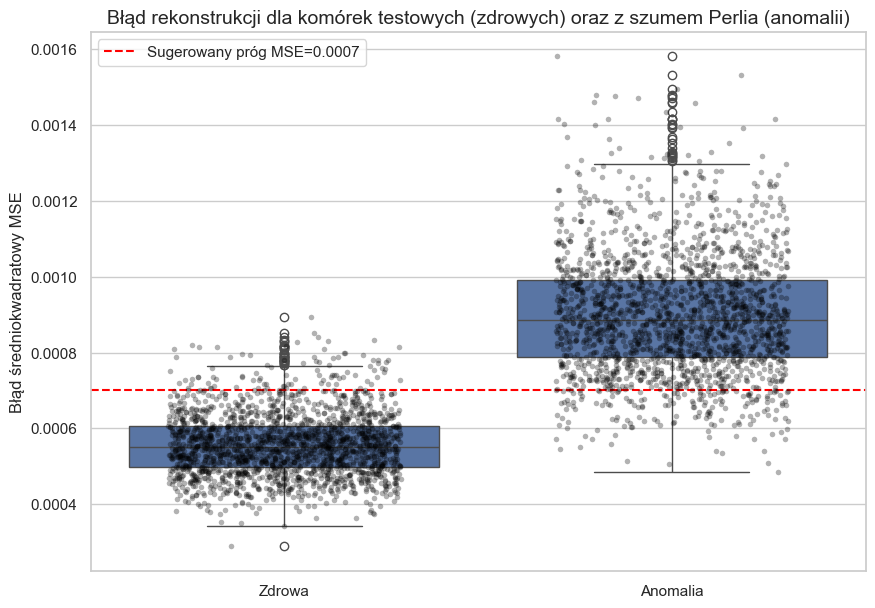

In [56]:
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(data=df_results, x='Typ', y='MSE')

sns.stripplot(data=df_results, x='Typ', y='MSE', color="black", alpha=0.3, jitter=0.3, size=4)

plt.title('Błąd rekonstrukcji dla komórek testowych (zdrowych) oraz z szumem Perlia (anomalii)', fontsize=14)
plt.ylabel('Błąd średniokwadratowy MSE', fontsize=12)
plt.xlabel('')

threshold = np.percentile(mse_test_per_image, 95)
plt.axhline(threshold, color='red', linestyle='--', label=f'Sugerowany próg MSE={threshold:.4f}')
plt.legend()

plt.show()

In [57]:
def print_summary(mse_anomaly,mse_healthy):
    mean_healthy = np.mean(mse_healthy)
    mean_anomaly = np.mean(mse_anomaly)
    ratio = mean_anomaly / mean_healthy


    print(f"Średni błąd dla zdrowych: {mean_healthy:.5f}")
    print(f"Średni błąd dla anomalii: {mean_anomaly:.5f}")
    print(f"Stosunek błędu (zdrowa/anomalia): {ratio:.2f}")
    if mean_anomaly > mean_healthy:
        print("Wniosek: Model skutecznie odróżnia anomalie (wyższy błąd rekonstrukcji).")
    else:
        print("Wniosek: Model ma trudności z odróżnieniem klas (błędy są zbliżone).")

In [58]:
print_summary(mse_test_per_image, mse_perlin_per_image)

Średni błąd dla zdrowych: 0.00090
Średni błąd dla anomalii: 0.00056
Stosunek błędu (zdrowa/anomalia): 0.62
Wniosek: Model ma trudności z odróżnieniem klas (błędy są zbliżone).


In [59]:
def generate_report(anomaly_data, decoded_anomaly_data, mse):
    for i in range(len(anomaly_data)):
        input_data = anomaly_data[i]
        output_data = decoded_anomaly_data[i]

    calculated_threshold, anomaly_mask, error_map = detect_anomaly_otsu_mse(input_data,output_data)
    otsu_thresholds.append([calculated_threshold, anomaly_mask, error_map])

    all_thresholds = [x[0] for x in otsu_thresholds]

    print(f'średni próg: {np.mean(all_thresholds)}')
    print(f'najmniejsza wartość progu: {np.min(all_thresholds)}')
    print(f'największa wartość progu: {np.max(all_thresholds)}')
    print(f'std: {np.std(all_thresholds)}')

    print('-------------------------------------------------------------------------')

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(7, 5))
    sns.histplot(x=all_thresholds, bins=15, kde=False)
    plt.axvline(np.mean(all_thresholds), color='red', linestyle='--', linewidth=2, label=f'Średnia: {np.mean(all_thresholds):.2f}')

    plt.title('Rozkład wartości progów Otsu dla zbioru anomalii', fontsize=14)
    plt.xlabel('Wartość progu')
    plt.ylabel('Liczba obrazów', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    print('------------------------------------------------------------------------------------------------')


    idx = random.randint(0, len(otsu_thresholds)-1)

    curr_org = anomaly_data[idx]
    curr_dec = decoded_anomaly_data[idx]

    idx_thresh = otsu_thresholds[idx][0]
    idx_mask =  otsu_thresholds[idx][1]
    idx_err = otsu_thresholds[idx][2]

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(20, 5))
    plt.subplot(1,4,1)
    plt.title("Obraz wejściowy", fontsize=14)
    plt.imshow(curr_org)
    plt.axis('off')


    plt.subplot(1,4,2)
    plt.title('Rekonstrukcja', fontsize=14)
    plt.imshow(curr_dec)
    plt.axis('off')


    plt.subplot(1,4,3)
    plt.imshow(idx_err, cmap='inferno')
    plt.title("Mapa Błędu (Różnica)", fontsize=14)
    plt.axis('off')

    plt.subplot(1,4,4)

    plt.imshow(curr_org)
    plt.imshow(idx_mask, cmap='gray')

    plt.title(f"Maska Anomalii Próg: {idx_thresh:.1f}", fontsize=14)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print('----------------------------------------------------------------------------------------')

    df_healthy = pd.DataFrame({'MSE': mse_test_per_image, 'Typ': 'Zdrowa'})
    df_cancer = pd.DataFrame({'MSE': mse, 'Typ': 'Anomalia'})
    df_results = pd.concat([df_healthy,df_cancer], ignore_index=True)

    plt.figure(figsize=(10, 7))
    sns.set_theme(style="whitegrid")

    ax = sns.boxplot(data=df_results, x='Typ', y='MSE')

    sns.stripplot(data=df_results, x='Typ', y='MSE', color="black", alpha=0.3, jitter=0.3, size=4)

    plt.title('Błąd rekonstrukcji dla komórek testowych (zdrowych) oraz anomalii', fontsize=14)
    plt.ylabel('Błąd średniokwadratowy MSE', fontsize=12)
    plt.xlabel('')

    threshold = np.percentile(mse_test_per_image, 95)
    plt.axhline(threshold, color='red', linestyle='--', label=f'Sugerowany próg MSE={threshold:.4f}')
    plt.legend()

    plt.show()

    print('--------------------------------------------------------------------')

    print_summary(mse_test_per_image, mse)

średni próg: 4.316341829085458
najmniejsza wartość progu: 3.0
największa wartość progu: 7.0
std: 0.580697172794226
-------------------------------------------------------------------------
------------------------------------------------------------------------------------------------


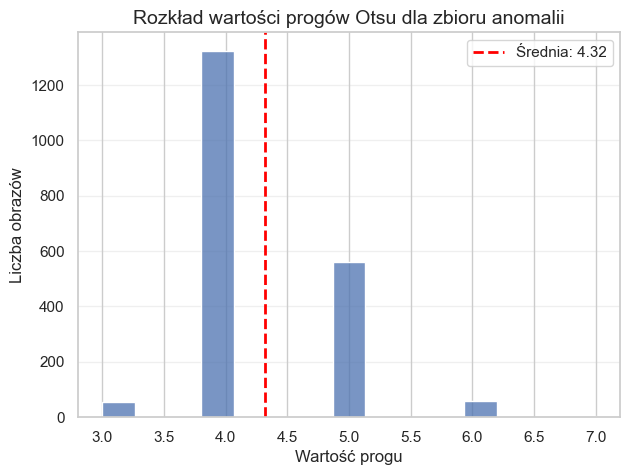

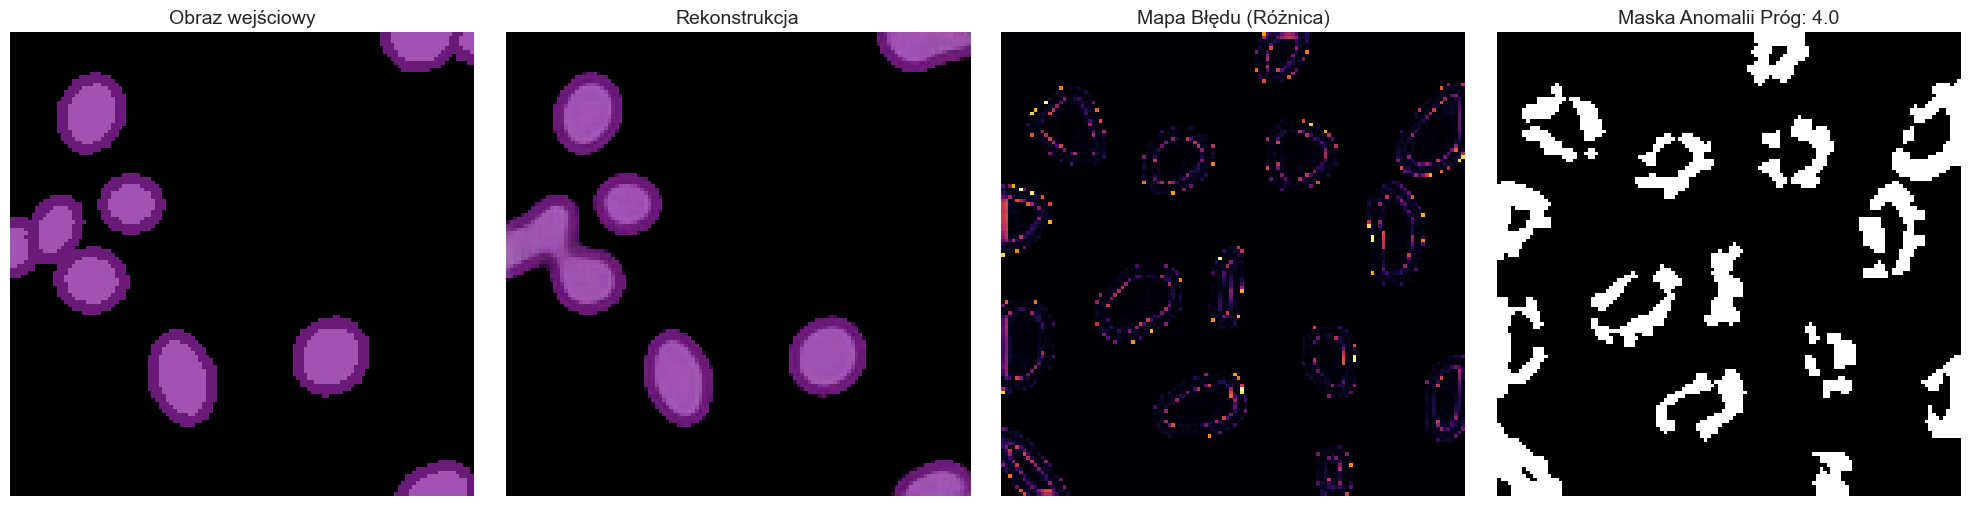

----------------------------------------------------------------------------------------


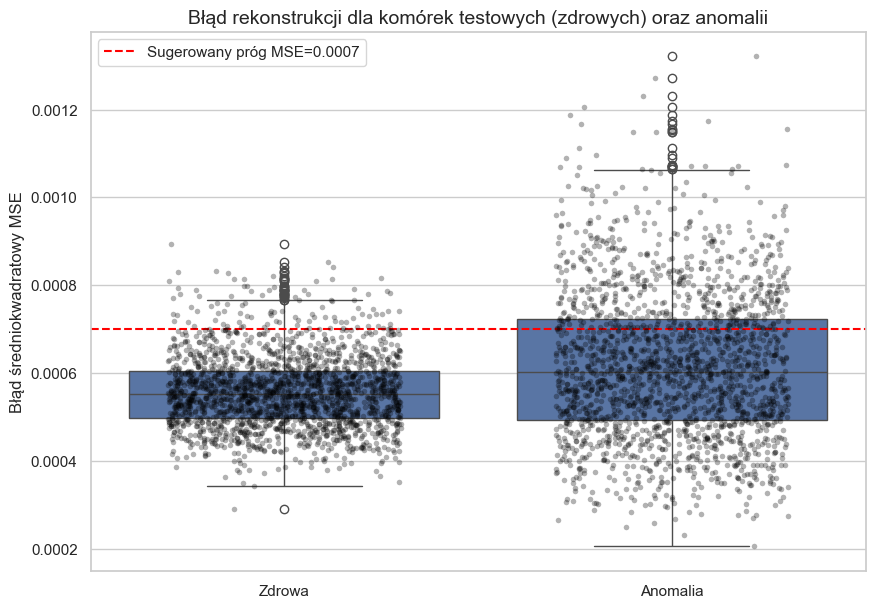

--------------------------------------------------------------------
Średni błąd dla zdrowych: 0.00062
Średni błąd dla anomalii: 0.00056
Stosunek błędu (zdrowa/anomalia): 0.91
Wniosek: Model ma trudności z odróżnieniem klas (błędy są zbliżone).


In [60]:
generate_report(x_gaussian_dist_data,decoded_gaussian_dist_cells, mse_gaussian_per_image)

API Error: 477 Exception during request to https://quota.app.eu-west-1.aws.jetbrains.ai/service/v5/quota/spend/verify with code 477: Out of quota
